<a href="https://colab.research.google.com/github/Dedlft/CNN/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
from IPython.display import clear_output

from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = kagglehub.dataset_download("pratik2901/multiclass-weather-dataset")
full_path = os.path.join(path, "Multi-class Weather Dataset")

print("Path to dataset files:", path)
print("Содержимое датасета:", os.listdir(full_path))

100%|██████████| 91.4M/91.4M [00:00<00:00, 141MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pratik2901/multiclass-weather-dataset/versions/3
Содержимое датасета: ['Sunrise', 'Rain', 'Cloudy', 'Shine']


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Трансформации для тренировочного набора (с аугментациями)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),   # случайное отражение по горизонтали
    transforms.RandomRotation(10),            # поворот на ±10 градусов
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Трансформации для тестового набора (без аугментаций)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [5]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

full_dataset = datasets.ImageFolder(root=full_path, transform=base_transform)

# Узнаем имена классов
class_names = full_dataset.classes
print("Классы:", class_names)
num_classes = len(class_names)

Классы: ['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [6]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.indices)

In [7]:
train_ratio = 0.8
train_size = int(train_ratio * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

train_indices = train_subset.indices
val_indices = val_subset.indices

train_dataset = TransformSubset(full_dataset, train_indices, transform=train_transform)
val_dataset   = TransformSubset(full_dataset, val_indices,   transform=val_transform)

In [8]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Размер train: {len(train_subset)} изображений")
print(f"Размер val:   {len(val_subset)} изображений")

Размер train: 900 изображений
Размер val:   225 изображений


In [17]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

In [18]:
if hasattr(model, "fc"):

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, len(class_names))

elif hasattr(model, "classifier"):

    if isinstance(model.classifier, nn.Sequential):
        num_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(num_features, len(class_names))
    else:
        num_features = model.classifier.in_features
        model.classifier = nn.Linear(num_features, len(class_names))

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")
model = model.to(device)
print(model)

Используемое устройство: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [20]:
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

Epoch 1/5
Train Loss: 1.0625
Val Loss: 0.7260
Val Accuracy: 85.33%


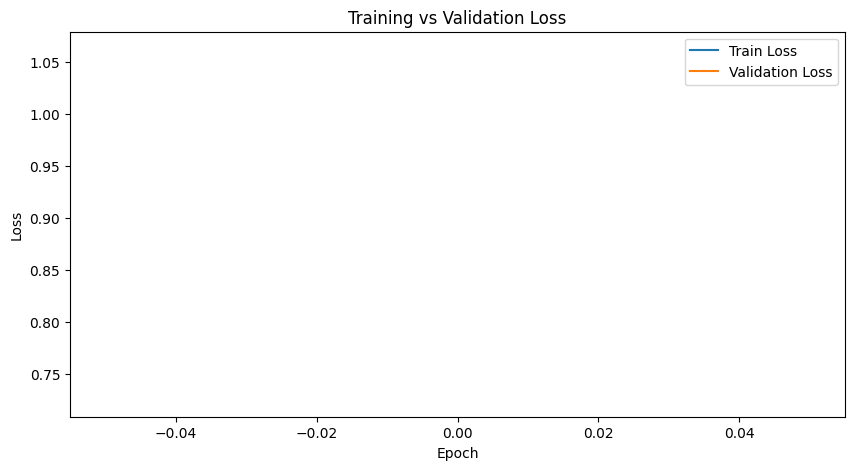

Epoch 2/5
Train Loss: 0.6048
Val Loss: 0.5185
Val Accuracy: 84.89%


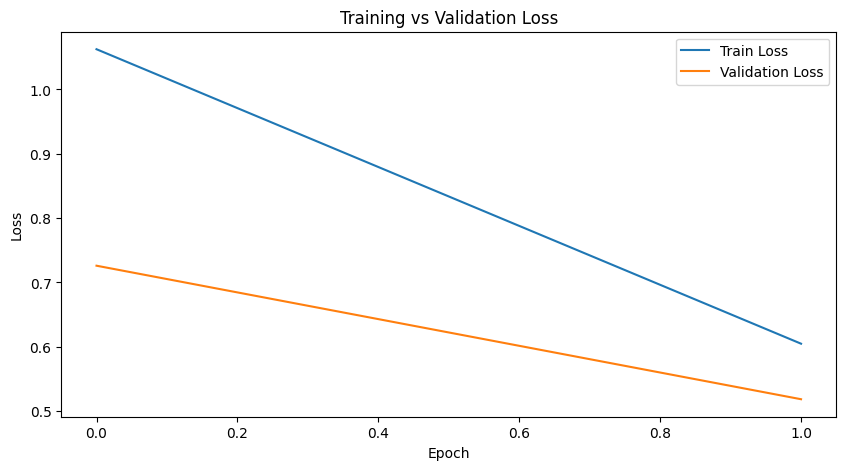

Epoch 3/5
Train Loss: 0.4305
Val Loss: 0.4259
Val Accuracy: 88.00%


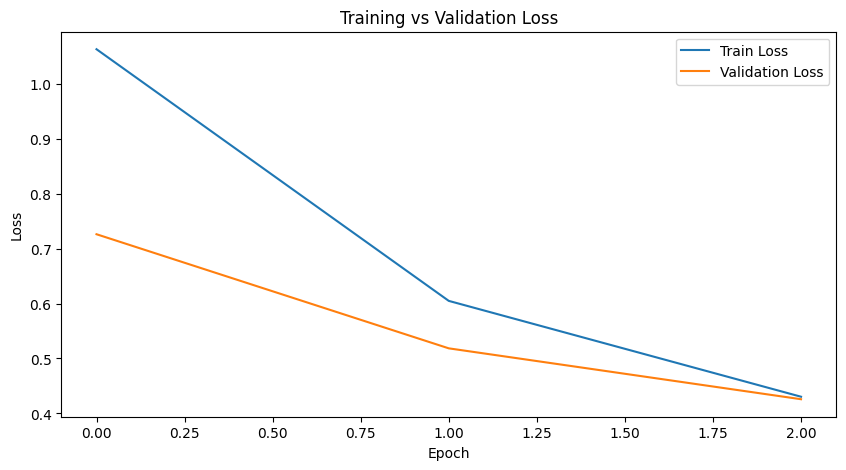

Epoch 4/5
Train Loss: 0.3732
Val Loss: 0.3537
Val Accuracy: 89.33%


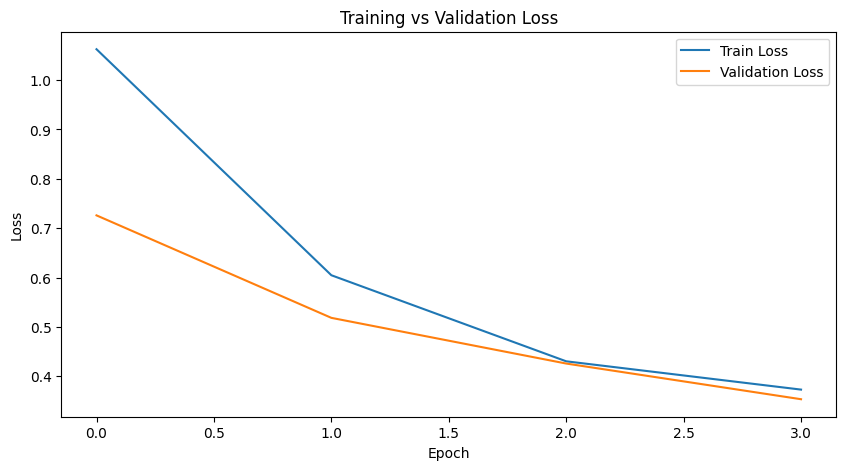

Epoch 5/5
Train Loss: 0.3167
Val Loss: 0.3035
Val Accuracy: 92.00%


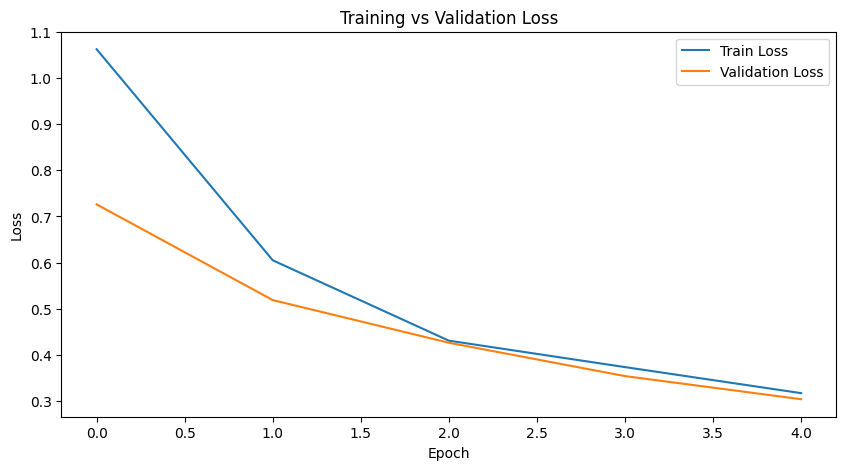

In [21]:
# Списки для хранения метрик по эпохам
train_losses = []
val_losses = []
val_accuracies = []

num_epochs = 5  # количество эпох (можно изменить)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):

    # --- ОБУЧЕНИЕ ---
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()          # обнуляем градиенты
        outputs = model(images)         # прямой проход
        loss = criterion(outputs, labels)  # вычисление потерь
        loss.backward()                  # обратное распространение
        optimizer.step()                  # обновление весов

        running_loss += loss.item() * images.size(0)  # суммируем потери по батчу

    # Средний train loss за эпоху (усреднённый по всем образцам)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- ВАЛИДАЦИЯ ---
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:   # обратите внимание: val_loader, а не test_loader
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_accuracy = 100 * correct / total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    # --- ВЫВОД МЕТРИК И ГРАФИКА ---
    #clear_output(wait=True)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f}")
    print(f"Val Accuracy: {epoch_val_accuracy:.2f}%")

    # График потерь
    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

In [22]:
# Сохраняем чекпоинт (веса модели + состояние оптимизатора + метрики)
checkpoint = {
    'epoch': num_epochs,                     # последняя завершённая эпоха
    'model_state_dict': model.state_dict(),  # веса модели
    'optimizer_state_dict': optimizer.state_dict(),  # состояние оптимизатора
    'train_losses': train_losses,            # история потерь на обучении
    'val_losses': val_losses,                # история потерь на валидации
    'val_accuracies': val_accuracies,        # история точности на валидации
    'class_names': class_names               # имена классов
}

# Сохраняем в файл
torch.save(checkpoint, 'weather_resnet18_checkpoint.pth')

print("Чекпоинт сохранён как 'weather_resnet18_checkpoint.pth'")

Чекпоинт сохранён как 'weather_resnet18_checkpoint.pth'


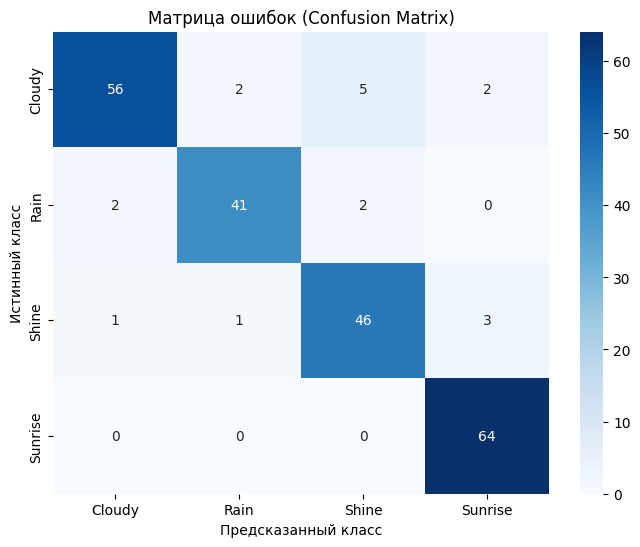

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.95      0.86      0.90        65
        Rain       0.93      0.91      0.92        45
       Shine       0.87      0.90      0.88        51
     Sunrise       0.93      1.00      0.96        64

    accuracy                           0.92       225
   macro avg       0.92      0.92      0.92       225
weighted avg       0.92      0.92      0.92       225



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# model.load_state_dict(torch.load('my_model.pth'))

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:          # используем val_loader
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,   # class_names должен быть определён (например, из dataset.classes)
    yticklabels=class_names
)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (Confusion Matrix)")
plt.show()

# 2. Детальный отчёт по классам
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))